# Lee–Carter Mortality Forecasting
### United States Period Life Tables, 1950–2019

---

## The Lee–Carter Model

Lee & Carter (1992) proposed decomposing the log central death rate $m(x,t)$ as

$$\boxed{\ln m(x,t) = a_x + b_x \, k_t + \varepsilon_{x,t}}$$

| Symbol | Name | Interpretation |
|--------|------|----------------|
| $a_x$ | Age pattern | Average log-mortality at age $x$ across all years. Captures the fixed shape of the mortality curve — the infant peak, childhood trough, accident hump in young adulthood, and the near-exponential rise into old age. |
| $b_x$ | Age sensitivity | How strongly age $x$ responds to a unit change in $k_t$. Large $b_x$ ages (typically infants and children) have improved the most historically; small $b_x$ ages (very old) have been more resistant to change. |
| $k_t$ | Mortality index | A single number per year summarising the overall level of mortality. Declining $k_t$ means improving mortality across all ages. It is the only time-varying quantity in the model. |
| $\varepsilon_{x,t}$ | Error | Age-period residual, assumed i.i.d. $\mathcal{N}(0,\sigma^2)$. |

### Identifiability

The decomposition is not unique without constraints. The standard normalisation is

$$\sum_x b_x = 1, \qquad \sum_t k_t = 0$$

The first fixes the scale of $b_x$ relative to $k_t$; the second centres $k_t$ so that $a_x$ is truly the time-average of the log-rates.

### Estimation by SVD

1. Compute $a_x = \frac{1}{T}\sum_t \ln m(x,t)$.
2. Centre: $Z_{x,t} = \ln m(x,t) - a_x$.
3. Singular value decomposition: $Z = U\,S\,V^\top$. The **leading rank-1 term** $b_x \approx u_1$, $k_t \approx s_1 v_1$ captures the dominant structure.
4. Rescale to satisfy the constraints above.

### Forecasting $k_t$

Because $k_t$ is approximately linear in time, the natural forecast model is a **random walk with drift** (ARIMA(0,1,0) + constant):

$$k_t = k_{t-1} + d + \sigma_k \, \varepsilon_t, \qquad \varepsilon_t \overset{\text{iid}}{\sim} \mathcal{N}(0,1)$$

The drift $d < 0$ is the average annual mortality improvement. Forecasting $k_t$ forward then projects the full age-specific mortality surface via $\hat{m}(x,t) = \exp(a_x + b_x \hat{k}_t)$.

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import pmdarima as pm

SEED = 20240608
np.random.seed(SEED)

plt.rcParams.update({
    "figure.figsize": (11, 5),
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "image.cmap": "viridis",
    "axes.grid": True,
    "axes.facecolor": "#EAEAF2",
    "grid.color": "white",
    "grid.linewidth": 0.8,
    "figure.facecolor": "white",
})

## 2. Data

In [2]:
life = pd.read_csv("data/bltper_1x1.txt", sep=r"\s+", skiprows=2, engine="python")
life["Age"] = life["Age"].astype(str).str.replace("+", "", regex=False).astype(int)
for col in ["mx", "qx", "ax", "lx", "dx", "Lx", "Tx", "ex"]:
    if col in life.columns:
        life[col] = pd.to_numeric(life[col], errors="coerce")
life["Year"] = life["Year"].astype(int)

YEAR_MIN, YEAR_MAX = 1950, 2019
AGE_MIN,  AGE_MAX  = 0, 99

window = life[
    life["Year"].between(YEAR_MIN, YEAR_MAX) &
    life["Age"].between(AGE_MIN, AGE_MAX)
].copy()

mxt    = window.pivot(index="Age", columns="Year", values="mx").sort_index()
logmxt = np.log(mxt)
ages   = mxt.index.to_numpy()
years  = mxt.columns.to_numpy()

print(f"Matrix: {len(ages)} ages x {len(years)} years  |  "
      f"ages {ages[0]}-{ages[-1]}, years {years[0]}-{years[-1]}")
mxt.iloc[:3, :5]

Matrix: 100 ages x 70 years  |  ages 0-99, years 1950-2019


Year,1950,1951,1952,1953,1954
Age,,,,,
0,0.03258,0.03231,0.03208,0.03067,0.02922
1,0.00235,0.00241,0.00236,0.00216,0.00196
2,0.00131,0.00137,0.00140,0.00125,0.00118


## 3. Exploratory Analysis

The heatmap shows $\ln m(x,t)$ across the full age–year surface. A strong vertical gradient reflects rising mortality with age ($a_x$); the left-to-right lightening reflects the secular decline driven by $k_t$.

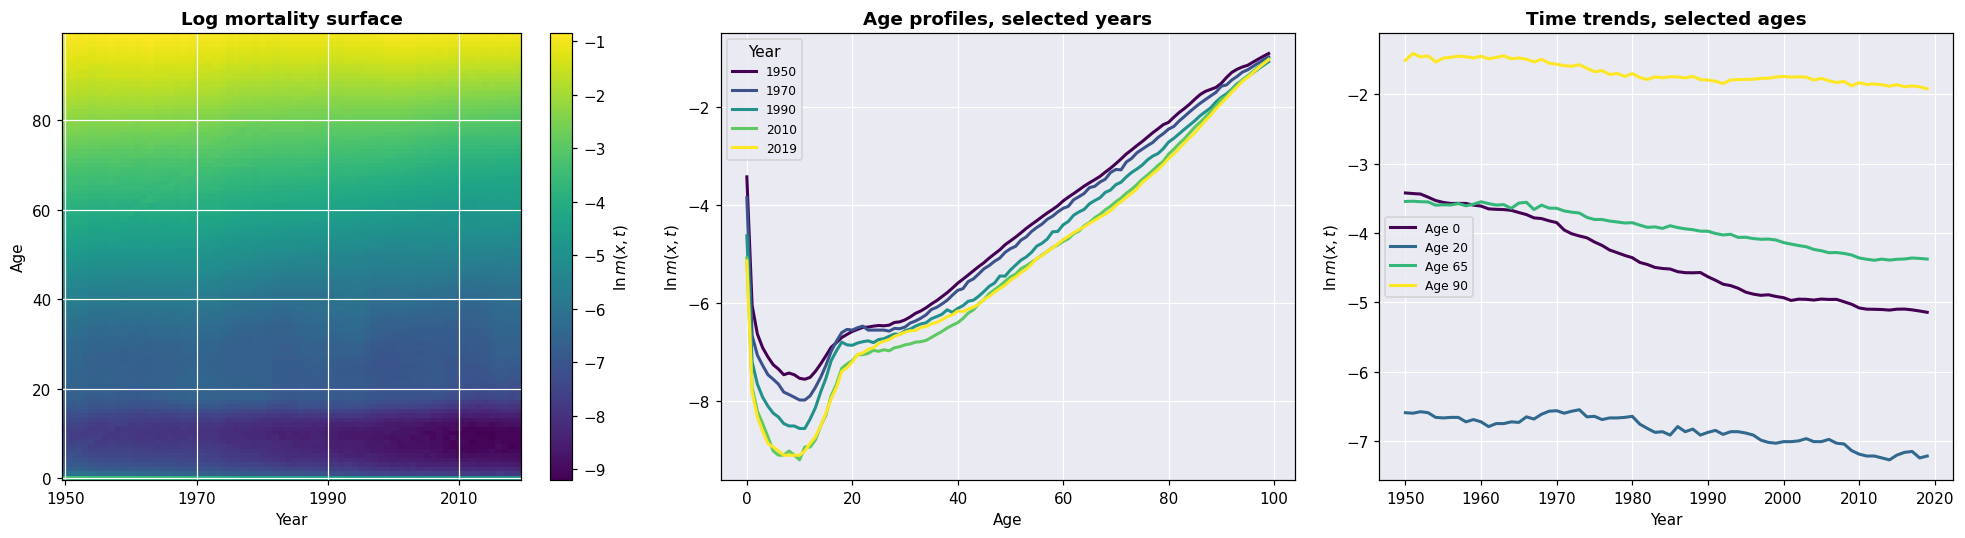

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
_cmap = plt.get_cmap("viridis")

# Log-mortality heatmap
ye = np.arange(years[0], years[-1]+2) - 0.5
ae = np.arange(ages[0],  ages[-1]+2)  - 0.5
mesh = axes[0].pcolormesh(ye, ae, logmxt.values, cmap="viridis")
fig.colorbar(mesh, ax=axes[0], label=r"$\ln m(x,t)$")
axes[0].set_title("Log mortality surface")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Age")
axes[0].set_xticks(years[::20]); axes[0].set_xticklabels(years[::20], rotation=0)
axes[0].set_yticks(ages[::20])

# Age profiles for selected years
profile_years = [1950, 1970, 1990, 2010, 2019]
cols = [_cmap(i/(len(profile_years)-1)) for i in range(len(profile_years))]
for yr, c in zip(profile_years, cols):
    axes[1].plot(ages, logmxt[yr].values, color=c, lw=2, label=str(yr))
axes[1].set_title("Age profiles, selected years")
axes[1].set_xlabel("Age"); axes[1].set_ylabel(r"$\ln m(x,t)$")
axes[1].legend(title="Year", fontsize=8)

# Time trends for selected ages
trend_ages = [0, 20, 65, 90]
cols2 = [_cmap(i/(len(trend_ages)-1)) for i in range(len(trend_ages))]
for age, c in zip(trend_ages, cols2):
    axes[2].plot(years, logmxt.loc[age].values, color=c, lw=2, label=f"Age {age}")
axes[2].set_title("Time trends, selected ages")
axes[2].set_xlabel("Year"); axes[2].set_ylabel(r"$\ln m(x,t)$")
axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

## 4. Model Fitting

The SVD of the centred log-rate matrix $Z = \ln m - a_x$ yields $b_x$ and $k_t$ directly. The fraction of variance captured by the first singular value measures how well a single time index represents the entire surface.

In [4]:
def fit_lee_carter(log_rates: pd.DataFrame) -> dict:
    ages_, years_ = log_rates.index, log_rates.columns
    M  = log_rates.to_numpy()
    ax = M.mean(axis=1)
    Z  = M - ax[:, None]

    U, S, Vt = np.linalg.svd(Z, full_matrices=False)
    bx = U[:, 0];  kt = S[0] * Vt[0, :]

    scale = bx.sum()
    bx /= scale;  kt *= scale;  kt -= kt.mean()
    if bx.sum() < 0:
        bx, kt = -bx, -kt

    return {
        "ax": pd.Series(ax, index=ages_),
        "bx": pd.Series(bx, index=ages_),
        "kt": pd.Series(kt, index=years_),
        "var_explained": float(S[0]**2 / (S**2).sum()),
    }

lc = fit_lee_carter(logmxt)
print(f"Variance explained by first component: {lc['var_explained']:.1%}")
print(f"sum(b_x) = {lc['bx'].sum():.6f}   sum(k_t) = {lc['kt'].sum():.2e}")

Variance explained by first component: 95.7%
sum(b_x) = 1.000000   sum(k_t) = 2.13e-14


### 4.1 Fitted Parameters

- **$a_x$** traces the classic age-mortality curve.
- **$b_x$** is largest where mortality has improved fastest (infants, children); smallest at the oldest ages where gains have been modest.
- **$k_t$** declines near-linearly — the visual signature that justifies projecting it with a random walk with drift.

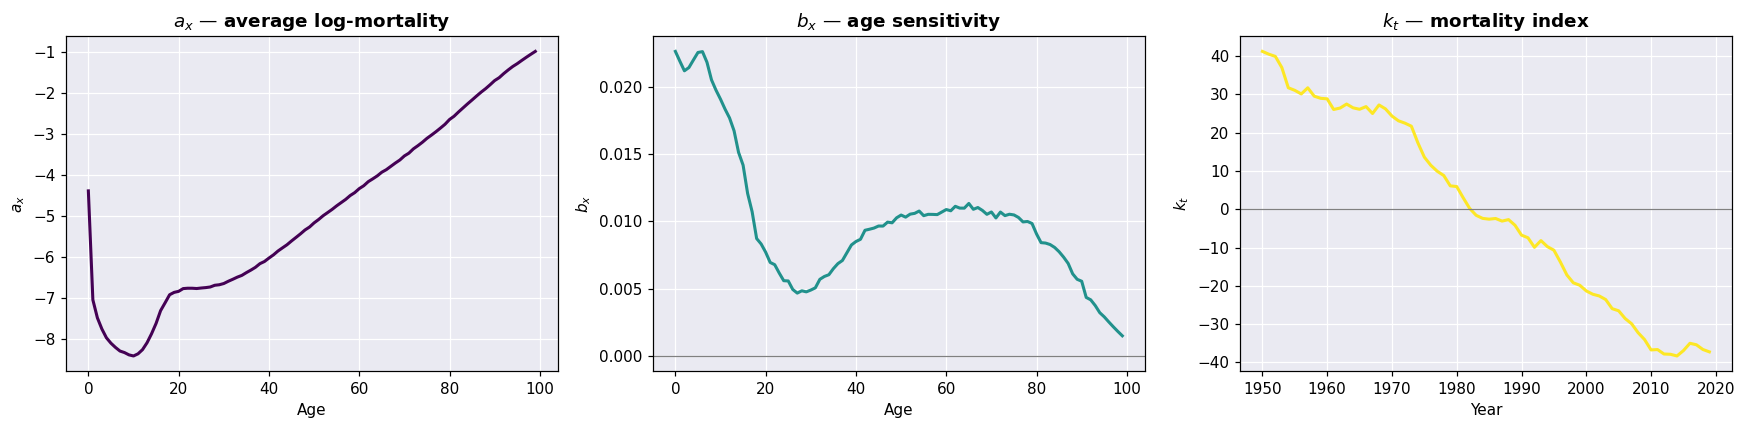

In [5]:
_cmap = plt.get_cmap("viridis")
c3 = [_cmap(0.0), _cmap(0.5), _cmap(1.0)]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(lc["ax"].index, lc["ax"].values, color=c3[0], lw=2)
axes[0].set_title(r"$a_x$ — average log-mortality")
axes[0].set_xlabel("Age"); axes[0].set_ylabel(r"$a_x$")

axes[1].plot(lc["bx"].index, lc["bx"].values, color=c3[1], lw=2)
axes[1].axhline(0, color="grey", lw=0.8)
axes[1].set_title(r"$b_x$ — age sensitivity")
axes[1].set_xlabel("Age"); axes[1].set_ylabel(r"$b_x$")

axes[2].plot(lc["kt"].index, lc["kt"].values, color=c3[2], lw=2)
axes[2].axhline(0, color="grey", lw=0.8)
axes[2].set_title(r"$k_t$ — mortality index")
axes[2].set_xlabel("Year"); axes[2].set_ylabel(r"$k_t$")

plt.tight_layout(); plt.show()

## 5. Diagnostics

The residual matrix $R_{x,t} = \ln m(x,t) - a_x - b_x k_t$ should be structureless noise if the single-factor model is adequate.

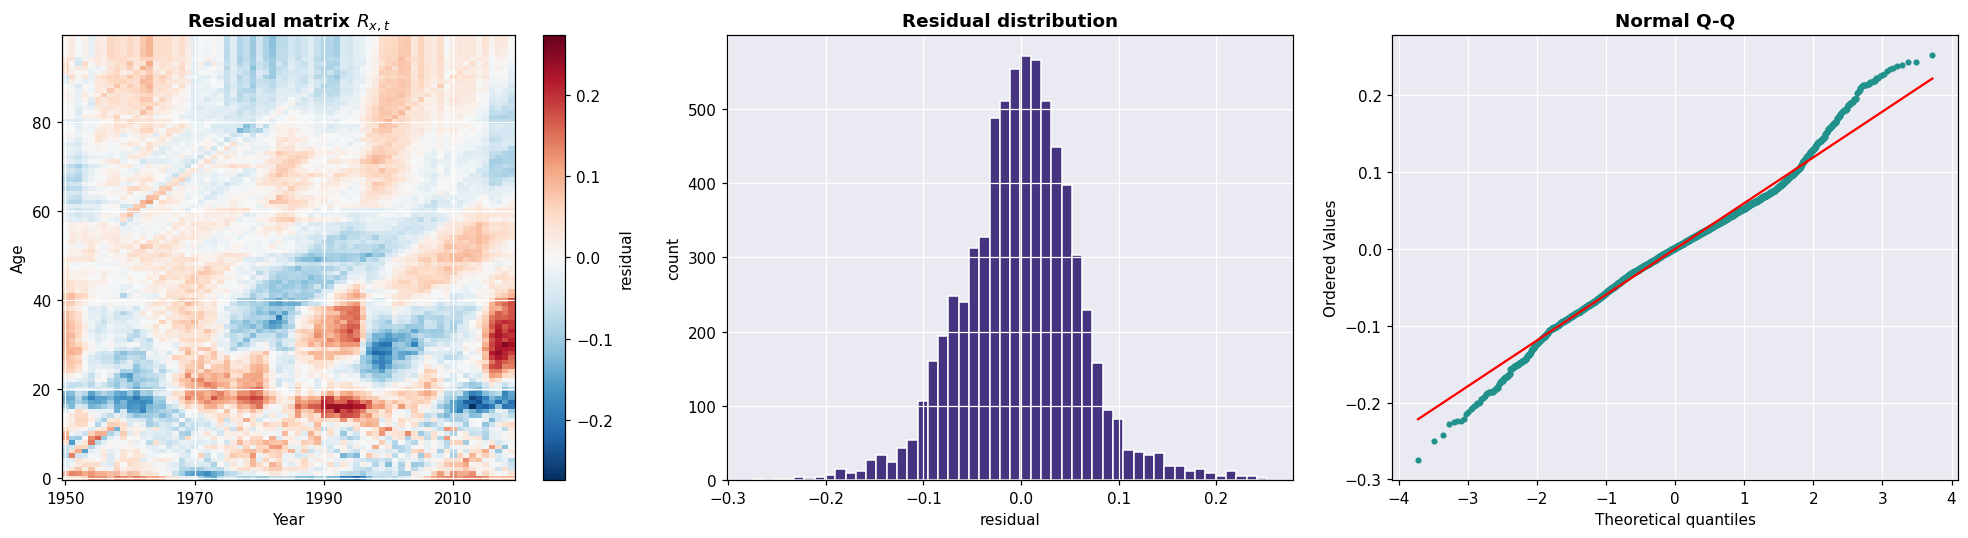

mean -0.0000  std 0.0599  skew 0.055


In [6]:
fitted    = lc["ax"].values[:, None] + np.outer(lc["bx"].values, lc["kt"].values)
resid_mat = logmxt.to_numpy() - fitted
resid_df  = pd.DataFrame(resid_mat, index=ages, columns=years)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
_cmap = plt.get_cmap("viridis")

# Residual heatmap
vmax = np.abs(resid_mat).max()
mesh = axes[0].pcolormesh(ye, ae, resid_df.values, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
fig.colorbar(mesh, ax=axes[0], label="residual")
axes[0].set_title(r"Residual matrix $R_{x,t}$")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Age")
axes[0].set_xticks(years[::20]); axes[0].set_xticklabels(years[::20], rotation=0)
axes[0].set_yticks(ages[::20])

# Histogram
flat = resid_mat.flatten()
axes[1].hist(flat, bins=50, color=_cmap(0.15), edgecolor="white")
axes[1].set_title("Residual distribution")
axes[1].set_xlabel("residual"); axes[1].set_ylabel("count")

# Q-Q plot
stats.probplot(flat, dist="norm", plot=axes[2])
axes[2].set_title("Normal Q-Q")
axes[2].get_lines()[0].set_color(_cmap(0.5))
axes[2].get_lines()[0].set_markersize(3)

plt.tight_layout(); plt.show()
print(f"mean {flat.mean():.4f}  std {flat.std():.4f}  skew {stats.skew(flat):.3f}")

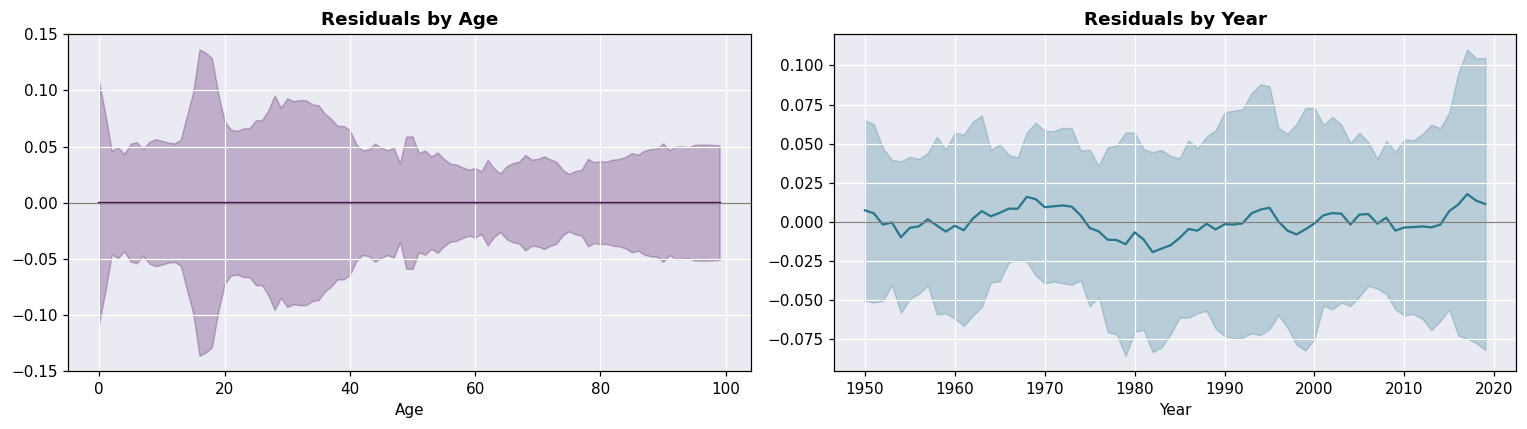

In [7]:
by_age  = pd.DataFrame({"mean": resid_df.mean(axis=1), "std": resid_df.std(axis=1)})
by_year = pd.DataFrame({"mean": resid_df.mean(axis=0), "std": resid_df.std(axis=0)})
_cmap = plt.get_cmap("viridis")
c0, c1 = _cmap(0.0), _cmap(0.4)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax_, df_, label_, c_ in [
    (axes[0], by_age,  "Age",  c0),
    (axes[1], by_year, "Year", c1),
]:
    ax_.plot(df_.index, df_["mean"], color=c_)
    ax_.fill_between(df_.index, df_["mean"]-df_["std"], df_["mean"]+df_["std"],
                     alpha=0.25, color=c_)
    ax_.axhline(0, color="grey", lw=0.8)
    ax_.set_title(f"Residuals by {label_}")
    ax_.set_xlabel(label_)

plt.tight_layout(); plt.show()

## 6. Forecasting $k_t$

We fit ARIMA models to $k_t$ and benchmark against the random walk with drift (ARIMA(0,1,0) + constant). White-noise residuals (Ljung–Box $p > 0.05$) confirm the model has captured all structure in $k_t$.

In [8]:
kt_vals = lc["kt"].values

auto = pm.auto_arima(kt_vals, seasonal=False, stepwise=True,
                     suppress_warnings=True, error_action="ignore",
                     with_intercept=True, trace=False)
print(f"auto_arima: ARIMA{auto.order}")

rwd = ARIMA(kt_vals, order=(0,1,0), trend="t").fit()
print(f"RWD drift = {rwd.params[0]:.4f} per year")

auto_arima: ARIMA(1, 1, 0)
RWD drift = -1.1370 per year


In [9]:
kt_resid = rwd.resid[1:]
lb = acorr_ljungbox(kt_resid, lags=[5, 10], return_df=True)
print("Ljung-Box\n", lb.round(4))
print(f"\nShapiro-Wilk  p = {stats.shapiro(kt_resid).pvalue:.3f}")

Ljung-Box
     lb_stat  lb_pvalue
5    3.7005     0.5933
10   7.1912     0.7073

Shapiro-Wilk  p = 0.483


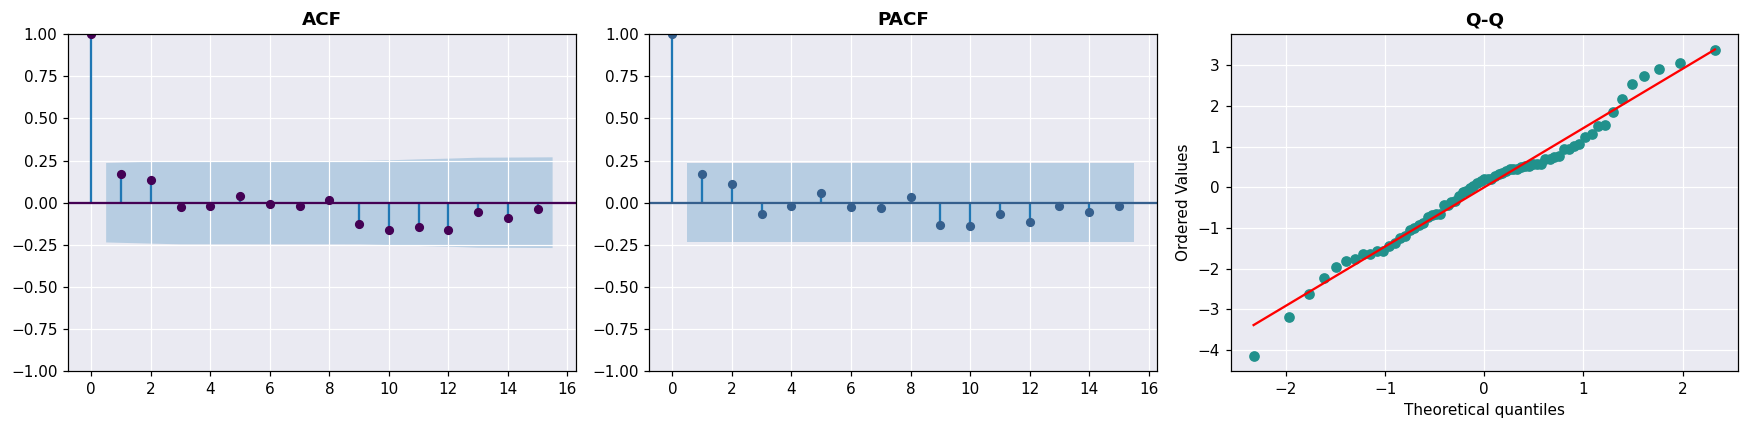

In [10]:
_cmap = plt.get_cmap("viridis")
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_acf( kt_resid, ax=axes[0], lags=15, color=_cmap(0.0)); axes[0].set_title("ACF")
plot_pacf(kt_resid, ax=axes[1], lags=15, method="ywm", color=_cmap(0.3)); axes[1].set_title("PACF")
stats.probplot(kt_resid, dist="norm", plot=axes[2]); axes[2].set_title("Q-Q")
axes[2].get_lines()[0].set_color(_cmap(0.5))
plt.tight_layout(); plt.show()

## 7. $k_t$ Projection

The 30-year central forecast is the historical drift extrapolated forward. Prediction intervals widen as $\sqrt{h}$ (characteristic of random-walk forecasts), reflecting growing uncertainty with horizon.

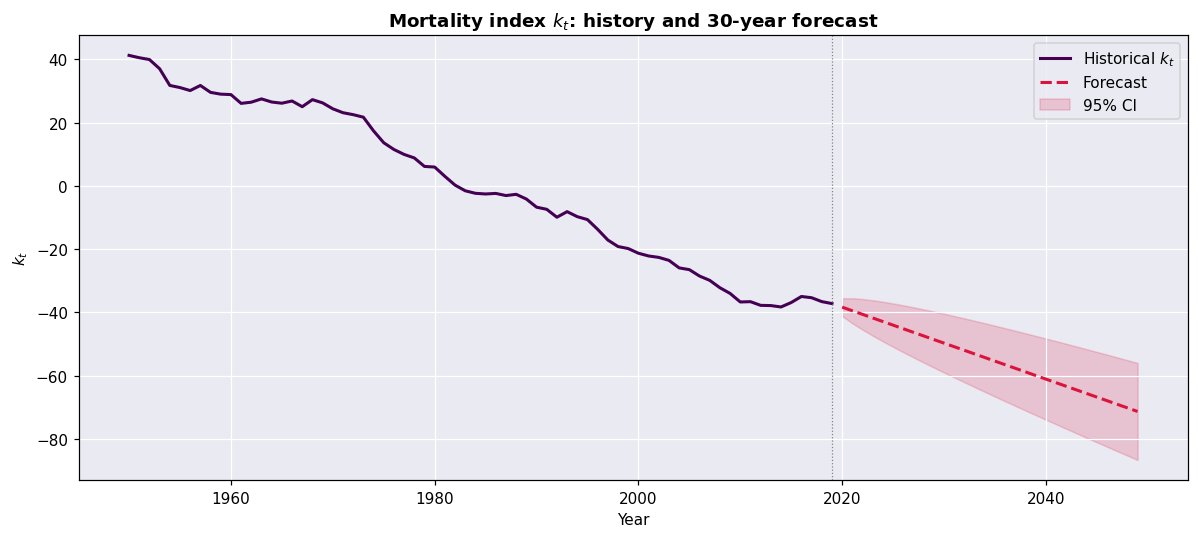

k_t in 2049: -71.33  (95% CI -86.67 to -56.00)


In [11]:
H = 30
future_years = np.arange(years[-1]+1, years[-1]+1+H)

fc       = rwd.get_forecast(steps=H)
kt_fc    = fc.predicted_mean
ci       = fc.conf_int(alpha=0.05)
kt_lo, kt_hi = ci[:, 0], ci[:, 1]

fig, ax = plt.subplots()
ax.plot(years, kt_vals, color=plt.get_cmap("viridis")(0.0), lw=2, label=r"Historical $k_t$")
ax.plot(future_years, kt_fc, color="crimson", lw=2, ls="--", label="Forecast")
ax.fill_between(future_years, kt_lo, kt_hi, color="crimson", alpha=0.18, label="95% CI")
ax.axvline(years[-1], color="grey", lw=0.8, ls=":")
ax.set_title(r"Mortality index $k_t$: history and 30-year forecast")
ax.set_xlabel("Year"); ax.set_ylabel(r"$k_t$")
ax.legend(); plt.tight_layout(); plt.show()

print(f"k_t in {future_years[-1]}: {kt_fc[-1]:.2f}  (95% CI {kt_lo[-1]:.2f} to {kt_hi[-1]:.2f})")

## 8. Projected Mortality Rates

Re-inflating the $k_t$ forecast back to age-specific rates via $\hat{m}(x,t) = \exp(a_x + b_x \hat{k}_t)$. Ages with larger $b_x$ show wider forecast bands.

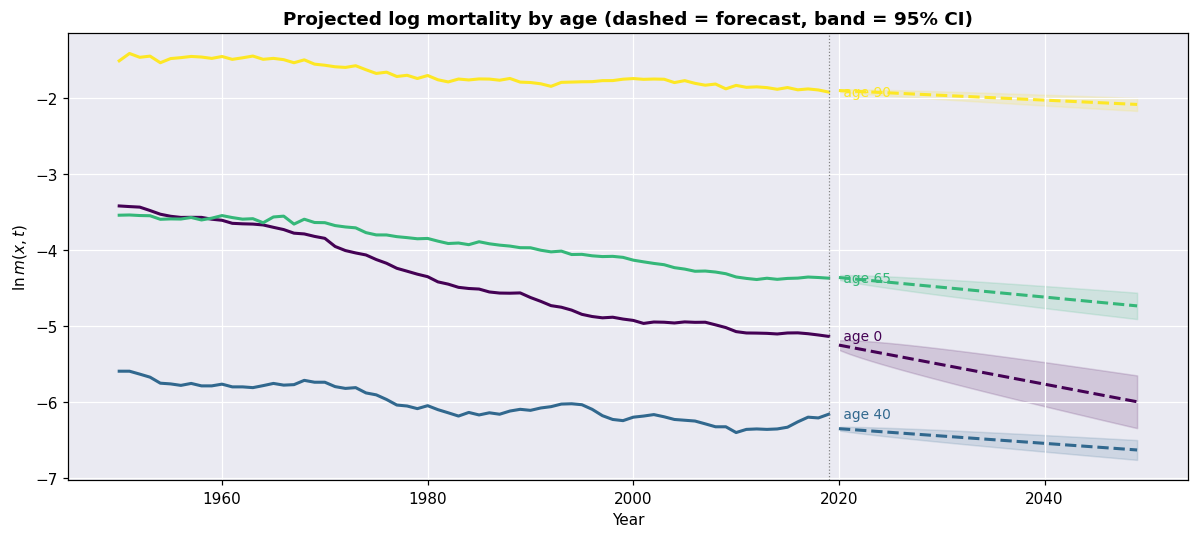

In [12]:
def project_rates(ax_, bx_, kt_path):
    log_p = ax_.values[:, None] + np.outer(bx_.values, np.asarray(kt_path))
    return pd.DataFrame(np.exp(log_p), index=ax_.index)

proj_mid = project_rates(lc["ax"], lc["bx"], kt_fc);  proj_mid.columns = future_years
proj_lo  = project_rates(lc["ax"], lc["bx"], kt_lo);  proj_lo.columns  = future_years
proj_hi  = project_rates(lc["ax"], lc["bx"], kt_hi);  proj_hi.columns  = future_years
rate_lo  = np.minimum(proj_lo, proj_hi)
rate_hi  = np.maximum(proj_lo, proj_hi)

show_ages = [0, 40, 65, 90]
_cmap = plt.get_cmap("viridis")
colors = [_cmap(i/(len(show_ages)-1)) for i in range(len(show_ages))]

fig, ax = plt.subplots()
for a, c in zip(show_ages, colors):
    ax.plot(years, logmxt.loc[a].values, color=c, lw=2)
    ax.plot(future_years, np.log(proj_mid.loc[a].values), color=c, lw=2, ls="--")
    ax.fill_between(future_years, np.log(rate_lo.loc[a].values),
                    np.log(rate_hi.loc[a].values), color=c, alpha=0.15)
    ax.text(years[-1]+1, logmxt.loc[a].values[-1], f" age {a}",
            color=c, va="center", fontsize=9)
ax.axvline(years[-1], color="grey", lw=0.8, ls=":")
ax.set_title("Projected log mortality by age (dashed = forecast, band = 95% CI)")
ax.set_xlabel("Year"); ax.set_ylabel(r"$\ln m(x,t)$")
plt.tight_layout(); plt.show()

## 9. Period Life Expectancy $e_0$

Life expectancy at birth is derived from the full age-schedule each year using a standard period life table. Higher rates translate to lower $e_0$, so the 95% CI for $e_0$ inverts the CI for $m(x,t)$.

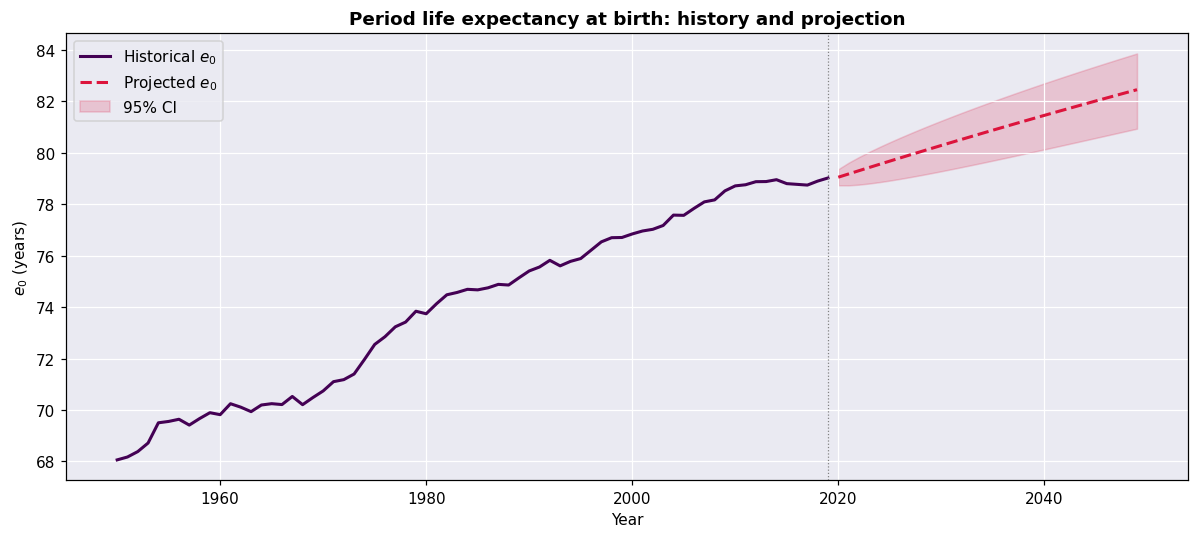

e0 2019 (observed):  79.02 yr
e0 2049 (projected): 82.45 yr  (95% CI 80.93–83.85)


In [13]:
def life_expectancy_at_birth(mx, a0=0.14):
    mx = np.asarray(mx, dtype=float)
    A  = len(mx)
    a  = np.full(A, 0.5); a[0] = a0
    qx = mx / (1 + (1-a)*mx); qx[-1] = 1.0
    lx = np.cumprod(np.concatenate([[1.0], 1-qx[:-1]]))
    dx = lx * qx
    Lx = np.empty(A)
    Lx[:-1] = lx[1:] + a[:-1]*dx[:-1]
    Lx[-1]  = lx[-1]/mx[-1] if mx[-1] > 0 else lx[-1]*a[-1]
    Tx = np.cumsum(Lx[::-1])[::-1]
    return Tx[0] / lx[0]

e0_hist = pd.Series([life_expectancy_at_birth(mxt[y].values) for y in years],        index=years)
e0_mid  = pd.Series([life_expectancy_at_birth(proj_mid[y].values) for y in future_years], index=future_years)
e0_lo   = pd.Series([life_expectancy_at_birth(rate_hi[y].values)  for y in future_years], index=future_years)
e0_hi   = pd.Series([life_expectancy_at_birth(rate_lo[y].values)  for y in future_years], index=future_years)

fig, ax = plt.subplots()
ax.plot(e0_hist.index, e0_hist.values, color=plt.get_cmap("viridis")(0.0), lw=2, label=r"Historical $e_0$")
ax.plot(e0_mid.index,  e0_mid.values,  color="crimson", lw=2, ls="--", label=r"Projected $e_0$")
ax.fill_between(future_years, e0_lo.values, e0_hi.values, color="crimson", alpha=0.18, label="95% CI")
ax.axvline(years[-1], color="grey", lw=0.8, ls=":")
ax.set_title("Period life expectancy at birth: history and projection")
ax.set_xlabel("Year"); ax.set_ylabel(r"$e_0$ (years)")
ax.legend(); plt.tight_layout(); plt.show()

print(f"e0 {years[-1]} (observed):  {e0_hist.iloc[-1]:.2f} yr")
print(f"e0 {future_years[-1]} (projected): {e0_mid.iloc[-1]:.2f} yr  "
      f"(95% CI {e0_lo.iloc[-1]:.2f}–{e0_hi.iloc[-1]:.2f})")

## 10. Backtesting

Out-of-sample validation: fit Lee–Carter on 1950–2000, forecast $k_t$ forward, and compare reconstructed rates against the held-out 2001–2019 observations.

In [14]:
TRAIN_END  = 2000
train_yrs  = years[years <= TRAIN_END]
test_yrs   = years[years >  TRAIN_END]

lc_tr   = fit_lee_carter(logmxt[train_yrs])
rwd_tr  = ARIMA(lc_tr["kt"].values, order=(0,1,0), trend="t").fit()
kt_test = rwd_tr.get_forecast(steps=len(test_yrs)).predicted_mean

logm_pred   = lc_tr["ax"].values[:, None] + np.outer(lc_tr["bx"].values, kt_test)
logm_pred   = pd.DataFrame(logm_pred, index=ages, columns=test_yrs)
logm_actual = logmxt[test_yrs]

err  = logm_actual - logm_pred
rmse = np.sqrt((err.values**2).mean())
mape = (np.abs(err.values) / np.abs(logm_actual.values)).mean() * 100
print(f"Backtest 2001-2019   RMSE = {rmse:.4f}   MAPE = {mape:.2f}%")

Backtest 2001-2019   RMSE = 0.1308   MAPE = 2.46%


In [15]:
groups = {"0-19":(0,19),"20-44":(20,44),"45-64":(45,64),"65-84":(65,84),"85-99":(85,99)}
rows = []
for name, (lo, hi) in groups.items():
    sel = (ages >= lo) & (ages <= hi)
    e = err.values[sel]; a = logm_actual.values[sel]
    rows.append({"Age group": name,
                 "RMSE": np.sqrt((e**2).mean()),
                 "MAPE %": (np.abs(e)/np.abs(a)).mean()*100})
pd.DataFrame(rows).set_index("Age group").style.format({"RMSE":"{:.4f}","MAPE %":"{:.2f}"})

,RMSE,MAPE %
Age group,,
0-19,0.1987,1.94
20-44,0.1228,1.43
45-64,0.1220,1.93
65-84,0.0638,1.44
85-99,0.1048,6.89


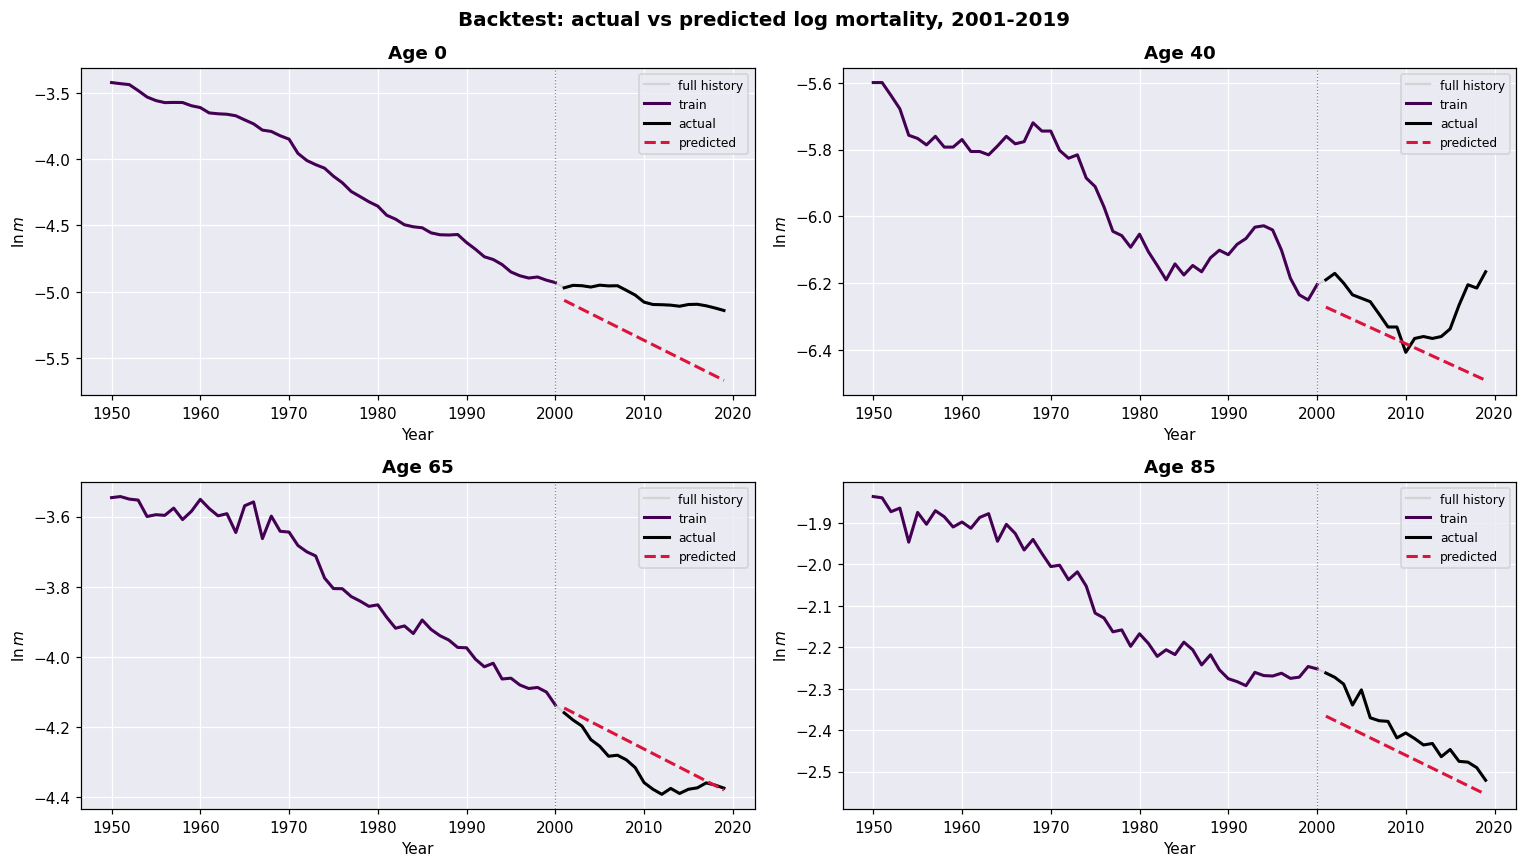

In [16]:
bt_ages = [0, 40, 65, 85]
_cmap = plt.get_cmap("viridis")
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for a, axx in zip(bt_ages, axes.flat):
    axx.plot(years, logmxt.loc[a].values, color="lightgrey", lw=1.5, label="full history")
    axx.plot(train_yrs, logmxt[train_yrs].loc[a].values,
             color=_cmap(0.0), lw=2, label="train")
    axx.plot(test_yrs, logm_actual.loc[a].values, color="black", lw=2, label="actual")
    axx.plot(test_yrs, logm_pred.loc[a].values,   color="crimson", lw=2, ls="--", label="predicted")
    axx.axvline(TRAIN_END, color="grey", lw=0.8, ls=":")
    axx.set_title(f"Age {a}"); axx.set_xlabel("Year"); axx.set_ylabel(r"$\ln m$")
    axx.legend(fontsize=8)
fig.suptitle("Backtest: actual vs predicted log mortality, 2001-2019",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## 11. Bootstrap Uncertainty

A residual bootstrap on the $k_t$ innovations produces empirical prediction intervals for $e_0$ that reflect the actual distribution of historical shocks rather than assuming normality.

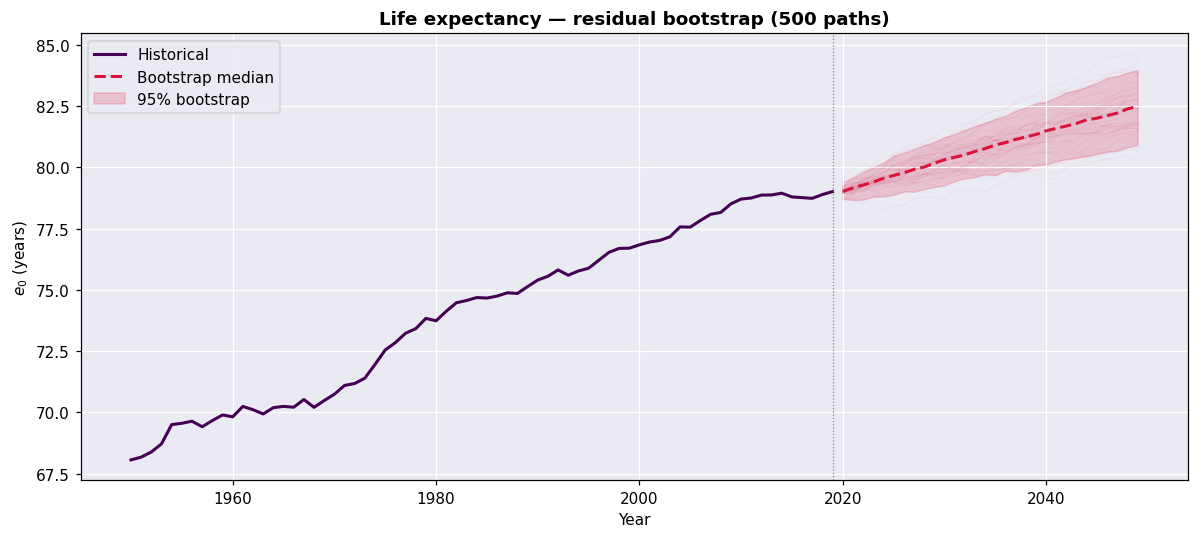

Bootstrap e0 2049: median 82.49  (95% 80.91–83.97)


In [17]:
N_BOOT   = 500
kt_diffs = np.diff(kt_vals)
drift_h  = kt_diffs.mean()
innov    = kt_diffs - drift_h

rng = np.random.default_rng(SEED)
e0_paths = np.empty((N_BOOT, H))
last_kt  = kt_vals[-1]

for b in range(N_BOOT):
    steps    = drift_h + rng.choice(innov, size=H, replace=True)
    kt_path  = last_kt + np.cumsum(steps)
    rates_b  = project_rates(lc["ax"], lc["bx"], kt_path)
    e0_paths[b] = [life_expectancy_at_birth(rates_b[c].values) for c in range(H)]

e0_med = np.median(e0_paths, axis=0)
e0_p05 = np.percentile(e0_paths,  2.5, axis=0)
e0_p95 = np.percentile(e0_paths, 97.5, axis=0)

fig, ax = plt.subplots()
ax.plot(e0_hist.index, e0_hist.values, color=plt.get_cmap("viridis")(0.0), lw=2, label="Historical")
for b in range(0, N_BOOT, 10):
    ax.plot(future_years, e0_paths[b], color="crimson", alpha=0.04, lw=0.7)
ax.plot(future_years, e0_med, color="crimson", lw=2, ls="--", label="Bootstrap median")
ax.fill_between(future_years, e0_p05, e0_p95, color="crimson", alpha=0.18, label="95% bootstrap")
ax.axvline(years[-1], color="grey", lw=0.8, ls=":")
ax.set_title(f"Life expectancy — residual bootstrap ({N_BOOT} paths)")
ax.set_xlabel("Year"); ax.set_ylabel(r"$e_0$ (years)")
ax.legend(); plt.tight_layout(); plt.show()

print(f"Bootstrap e0 {future_years[-1]}: median {e0_med[-1]:.2f}  "
      f"(95% {e0_p05[-1]:.2f}–{e0_p95[-1]:.2f})")